In [1]:
# Symbolic Formulation
import numpy as np
import sympy as sp
import time
import matplotlib.pyplot as plt

E = sp.symbols('E')
U = sp.symbols('U')
t = sp.symbols('t')

# n = number of atoms per ring
n = 17
# alpha matrix is interactions within rings
alpha = E*sp.eye(n)-U*sp.eye(n)
# tau matrix is interactions between rings
tau = t*sp.I*sp.eye(n)

iterations=2
h_old = alpha
tau_old = tau
for i in range(iterations):
    h_new = h_old - tau_old*tau_old.T.conj()*h_old.inv()
    tau_new = tau_old*tau_old.T.conj()*h_old.inv()
    h_old = h_new
    tau_old = tau_new
h_new
g = h_new.inv()
g

AttributeError: 'MutableDenseMatrix' object has no attribute 'conj'

In [295]:
# 1D Atomic Chain

# n = number of atoms per ring
n = 1
# E energy mode
E = -1+1j*10**(-8)

# N_P = number of rings in probe
N_P = 1
# a_P = probe interaction self energy
a_P = 0.5
# a_C = connection interaction energy
a_C = 0.4
H_P = a_P*(np.diag(2*np.ones(N_P))+np.diag(-np.ones(N_P-1),k=-1)+np.diag(-np.ones(N_P-1),k=1))
H_P_L = H_P
H_P_L[N_P-1,N_P-1] = a_P+a_C
H_P_R = H_P
H_P_R[0,0] = a_P+a_C

# N_D = number of rings in device
N_D = 2
# a_D = device interaction self energy
a_D = 0.6
H_D = a_D*(np.diag(2*np.ones(N_D))+np.diag(-np.ones(N_D-1),k=-1)+np.diag(-np.ones(N_D-1),k=1))
H_D[0,0] = a_D+a_C
H_D[N_D-1,N_D-1] = a_D+a_C

Tau_L=np.zeros((N_P,N_D))
Tau_L[N_P-1,0]=-a_C
Tau_R=np.zeros((N_P,N_D))
Tau_R[0,N_D-1]=-a_C

# Total Hamiltonian
H_tot = np.block([[H_P_L,Tau_L,np.zeros((N_P,N_P))],[Tau_L.T.conj(),H_D,Tau_R.T.conj()],[np.zeros((N_P,N_P)),Tau_R,H_P_R]])
matprint(H_tot)


# Computing Surface Green's Functions
start_time = time.time()
Sigma_L = np.matmul(np.matmul(Tau_L.T.conj(),np.linalg.inv(E*np.identity(N_P)-H_P_L)),Tau_L)
end_time = time.time()

print(Sigma_L[0,0],end_time-start_time)

# Decimation Method
iterations=5
h_s_old = E-(a_P+a_C)
h_b_old = E-2*a_C
tau_old = a_P

start_time = time.time()
for i in range(iterations):
    h_s_new = h_s_old-tau_old**2/h_b_old
    h_b_new = h_b_old-2*tau_old**2/h_b_old
    tau_new = -tau_old**2/h_b_old
    h_s_old=h_s_new
    h_b_old=h_b_new
    tau_old=tau_new
end_time = time.time()

Sigma_L = np.zeros((N_D,N_D),dtype=np.complex128)
Sigma_L[0,0] = a_C**2*1/h_s_new

Sigma_R = np.zeros((N_D,N_D),dtype=np.complex128)
Sigma_R[N_D-1,N_D-1] = a_C**2*1/h_s_new

print(Sigma_L[0,0],end_time-start_time)


 0.9  -0.4     0     0  
-0.4     1  -0.6     0  
   0  -0.6     1  -0.4  
   0     0  -0.4   0.9  
(-0.08421052631578947-4.4321329639889193e-10j) 0.0001888275146484375
(-0.09151582641644064-5.764915847753829e-10j) 8.535385131835938e-05


In [251]:
# Calculating Current
G_D = np.linalg.inv(E*np.identity(N_D)- H_D - Sigma_L - Sigma_R)
Gamma_L = (Sigma_L-Sigma_L.T.conj())*1j
Gamma_R = (Sigma_R-Sigma_R.T.conj())*1j

I=np.matrix.trace(np.matmul(np.matmul(np.matmul(G_D.T.conj(),Gamma_L),G_D),Gamma_R))
print(I)

0j


In [179]:
# 3D recreation

# n = number of atoms per ring
n=1

# a_C = connection energy
a_C=0.3
# Connection Matrix
H_C = a_C*np.diag(np.ones(n))

# a_P = probe ineraction energy
a_P = 0.4
# H_P_C1 connection to 2 atoms probe
H_P_C1 = -a_P/2*(np.diag(np.ones(n)))
# H_P_C2 connection to 1 atoms probe
H_P_C2 = -a_P/2*(np.diag(np.ones(n)))

# H_P_a atom self energy probe
H_P_a = a_P*(np.diag(np.ones(n)))

# N_P = number of rings in probe
N_P=60

H_P=np.zeros((n*N_P,n*N_P))
for i in range(N_P):
    H_P[i*n:(i+1)*n,i*n:(i+1)*n]=H_P_a
    if i < N_P-1:
        if i % 4 == 0:
            H_P[i*n:(i+1)*n,(i+1)*n:(i+2)*n]=H_P_C1.T.conj()
        if (i+2) % 4 == 0:
            H_P[i*n:(i+1)*n,(i+1)*n:(i+2)*n]=H_P_C1
        if (i+1) % 2 == 0:
            H_P[i*n:(i+1)*n,(i+1)*n:(i+2)*n]=H_P_C2
    if i < N_P-1:
        if i % 4 == 0:
            H_P[(i+1)*n:(i+2)*n,i*n:(i+1)*n]=H_P_C1
        if (i+2) % 4 == 0:
            H_P[(i+1)*n:(i+2)*n,i*n:(i+1)*n]=H_P_C1.T.conj()
        if (i+1) % 2 == 0:
            H_P[(i+1)*n:(i+2)*n,i*n:(i+1)*n]=H_P_C2            

# a_D = device ineraction energy
a_D = 0.7
# H_D_C1 connection to 2 atoms device
H_D_C1 = -a_D/4*((np.diag(np.ones(n))+np.diag(np.ones(n-1),k=-1)))
H_D_C1[0,n-1] = -a_D/4
# H_D_C2 connection to 1 atoms device
H_D_C2 = -a_D/2*(np.diag(np.ones(n)))

# H_D_a atom self energy device
H_D_a = a_D*(np.diag(np.ones(n)))

# N_D = number of rings in device
N_D=2

H_D=np.zeros((n*N_D,n*N_D))
for i in range(N_D):
    H_D[i*n:(i+1)*n,i*n:(i+1)*n]=H_D_a
    if i < N_D-1:
        if (i % 4) % 4 == 0:
            H_D[i*n:(i+1)*n,(i+1)*n:(i+2)*n]=H_D_C1.T.conj()
        if (i+2) % 4 == 0:
            H_D[i*n:(i+1)*n,(i+1)*n:(i+2)*n]=H_D_C1
        if (i+1) % 2 == 0:
            H_D[i*n:(i+1)*n,(i+1)*n:(i+2)*n]=H_D_C2
    if i < N_D-1:
        if i % 4 == 0:
            H_D[(i+1)*n:(i+2)*n,i*n:(i+1)*n]=H_D_C1
        if (i+2) % 4 == 0:
            H_D[(i+1)*n:(i+2)*n,i*n:(i+1)*n]=H_D_C1.T.conj()
        if (i+1) % 2 == 0:
            H_D[(i+1)*n:(i+2)*n,i*n:(i+1)*n]=H_D_C2            

# Total Hamiltonian
H_tot = np.block([[H_P,np.zeros((n*N_P,n*N_D)),np.zeros((n*N_P,n*N_P))],[np.zeros((n*N_D,n*N_P)),H_D,np.zeros((n*N_D,n*N_P))],[np.zeros((n*N_P,n*N_P)),np.zeros((n*N_P,n*N_D)),H_P]])
# Add connection terms
H_tot[n*(N_P-1):n*N_P,n*N_P:n*(N_P+1)]=H_C
H_tot[n*N_P:n*(N_P+1),n*(N_P-1):n*N_P]=H_C.T.conj()
H_tot[n*(N_P+N_D-1):n*(N_P+N_D),n*(N_P+N_D):n*(N_P+N_D+1)]=H_C.T.conj()
H_tot[n*(N_P+N_D):n*(N_P+N_D+1),n*(N_P+N_D-1):n*(N_P+N_D)]=H_C

# Mode Space Approximation
V = np.zeros((n*(2*N_P+N_D),n*(2*N_P+N_D)),dtype=np.complex128)
for i in range(2*N_D+N_P):
    V[i*n:(i+1)*n,i*n:(i+1)*n]=np.linalg.eig(H_D_C1).eigenvectors

H_mode=np.matmul(V.T.conj(),np.matmul(H_tot,V))

H_P_mode = H_mode[0:(n*N_P),0:(n*N_P)]

# Computing Surface Green's Functions
start_time = time.time()
surface_g = np.linalg.inv(E*(1+(1j/10))*np.identity(N_P*n)-H_P_mode)
end_time = time.time()

matprint(surface_g[0:n,0:n])
print(end_time-start_time)
print('________________________________')

# Decimation Method
iterations=8
start_time = time.time()

h_0 = E*(1+(1j/10))*np.identity(n)-H_P_mode[0:n,0:n]
tau_0 = H_P_mode[n:2*n,0:n]
h_1 = h_0-np.matmul(np.matmul(tau_0,np.linalg.inv(h_0)),tau_0.T.conj())
h_star_1 = h_0-np.matmul(np.matmul(tau_0,np.linalg.inv(h_0)),tau_0.T.conj())- np.matmul(np.matmul(tau_0.T.conj(),np.linalg.inv(h_0)),tau_0)
tau_1 = np.matmul(np.matmul(tau_0,np.linalg.inv(h_0)),tau_0)
tau_star_1 = np.matmul(np.matmul(tau_0.T.conj(),np.linalg.inv(h_0)),tau_0.T.conj())
h_old = h_1
h_star_old = h_star_1
tau_old = tau_1
tau_star_old = tau_star_1
for i in range(iterations-1):
    h_new = h_old-np.matmul(np.matmul(tau_old,np.linalg.inv(h_star_old)),tau_star_old)
    h_star_new = h_star_old-np.matmul(np.matmul(tau_old,np.linalg.inv(h_star_old)),tau_star_old)--np.matmul(np.matmul(tau_star_old,np.linalg.inv(h_star_old)),tau_old)
    tau_new = np.matmul(np.matmul(tau_old,np.linalg.inv(h_star_old)),tau_old)
    tau_star_new = np.matmul(np.matmul(tau_star_old.T.conj(),np.linalg.inv(h_star_old)),tau_star_old.T.conj())
    h_old = h_new
    h_star_old = h_star_new
    tau_old = tau_new
    tau_star_old = tau_star_new
end_time = time.time()

matprint(np.linalg.inv(h_new))
print(end_time-start_time)


1.09004-4.25903j  
0.0018341541290283203
________________________________
-1.18245-4.72365j  
0.001990079879760742


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


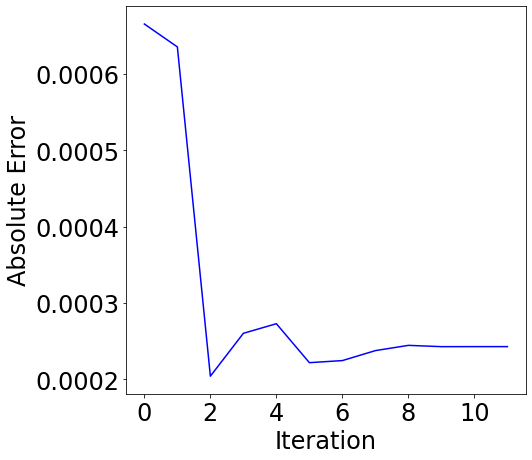

In [162]:
# Set up random matrices

trials = 1
iterations = 12
errorlist=np.zeros((trials,iterations,1),dtype=np.complex128)

for k in range(trials):

    n = 50
    alpha_N1 = 1/np.sqrt(2)*(np.random.random((n,n)))
    alpha_N2 = 1/np.sqrt(2)*(np.random.random((n,n))+1j*np.random.random((n,n)))
    tau_N1 = 1/np.sqrt(2)*(np.random.random((n,n)))
    tau_N2 = 1/np.sqrt(2)*(np.random.random((n,n))+1j*np.random.random((n,n)))

    N = 80
    H = np.zeros((N*n,N*n),dtype=np.complex128)
    E = 0
    for i in range(N):
        if i == 0:
            H[i*n:(i+1)*n,i*n:(i+1)*n]=E*np.diag(np.ones(n))-alpha_N1
            H[i*n:(i+1)*n,(i+1)*n:(i+2)*n]=-tau_N1
            H[(i+1)*n:(i+2)*n,i*n:(i+1)*n]=-tau_N1.T.conj()
        elif i == 1:
            H[i*n:(i+1)*n,i*n:(i+1)*n]=E*np.diag(np.ones(n))-alpha_N2
            H[i*n:(i+1)*n,(i+1)*n:(i+2)*n]=-tau_N2
            H[(i+1)*n:(i+2)*n,i*n:(i+1)*n]=-tau_N2.T.conj()
        else:
            #H[i*n:(i+1)*n,i*n:(i+1)*n]=E*np.diag(np.ones(n))-alpha_N2
            H[i*n:(i+1)*n,i*n:(i+1)*n]=E*np.diag(np.ones(n))-(np.random.random((n,n))+1j*np.random.random((n,n)))
            if i < N-1:
                #[i*n:(i+1)*n,(i+1)*n:(i+2)*n]=-tau_N2
                #[(i+1)*n:(i+2)*n,i*n:(i+1)*n]=-tau_N2.T.conj()            
                tau_i = np.random.random((n,n))+1j*np.random.random((n,n))
                H[i*n:(i+1)*n,(i+1)*n:(i+2)*n]=-tau_i
                H[(i+1)*n:(i+2)*n,i*n:(i+1)*n]=-tau_i.T.conj()

    # Direct inverse
    start_time = time.time()
    g_direct = np.linalg.inv(H)
    end_time = time.time()
    time_direct = end_time-start_time

    # Decimation Technique
    start_time = time.time()

    mu_0 = E*np.diag(np.ones(n))-alpha_N1
    nu_0 = E*np.diag(np.ones(n))-alpha_N2
    gamma_0 = tau_N1
    zeta_0 = tau_N2
    mu_old = mu_0-np.matmul(np.matmul(gamma_0,np.linalg.inv(nu_0)),gamma_0.T.conj())
    nu_old = nu_0-np.matmul(np.matmul(zeta_0,np.linalg.inv(nu_0)),gamma_0.T.conj())- np.matmul(np.matmul(gamma_0.T.conj(),np.linalg.inv(nu_0)),zeta_0)
    kappa_1 = np.matmul(np.matmul(gamma_0,np.linalg.inv(nu_0)),zeta_0)
    kappa_old = kappa_1
    gamma_old = np.matmul(np.matmul(gamma_0.T.conj(),np.linalg.inv(nu_0)),gamma_0.T.conj())
    zeta_old = np.matmul(np.matmul(zeta_0,np.linalg.inv(nu_0)),zeta_0)

    kappalist=np.zeros((iterations,1),dtype=np.complex128)
    kappalist[0]=abs(np.trace(kappa_old/kappa_1*1/n))
    errorlist[k][0]=abs(sum(sum(np.linalg.inv(mu_0)-g_direct[0:n,0:n])))/(n**2)
    
    for i in range(iterations-1):
        mu_new = mu_old - np.matmul(np.matmul(kappa_old,np.linalg.inv(nu_old)),gamma_old)
        nu_new = nu_old-np.matmul(np.matmul(zeta_old,np.linalg.inv(nu_old)),gamma_old)- np.matmul(np.matmul(gamma_old,np.linalg.inv(nu_old)),zeta_old)
        kappa_new = np.matmul(np.matmul(kappa_old,np.linalg.inv(nu_old)),zeta_old)
        gamma_new = np.matmul(np.matmul(gamma_old,np.linalg.inv(nu_old)),gamma_old)
        zeta_new = np.matmul(np.matmul(zeta_old,np.linalg.inv(nu_old)),zeta_old)


        mu_old = mu_new
        nu_old = nu_new
        kappa_old = kappa_new
        gamma_old = gamma_new
        zeta_old = zeta_new
        kappalist[i+1] = abs(np.trace(kappa_old/kappa_1*1/n))
        errorlist[k][i+1] = abs(sum(sum(np.linalg.inv(mu_new)-g_direct[0:n,0:n])))/(n**2)
        
    end_time = time.time()

    time_decimation = end_time-start_time


    
fig, (ax1) = plt.subplots(1, 1, figsize=(7.5, 6.5))
ax1.tick_params(axis='both', which='major', labelsize=24)

for k in range(trials):
    ax1.plot(errorlist[k], color='blue')
    
ax1.set_xlabel('Iteration', size=24)
ax1.set_ylabel('Absolute Error', size=24)
ax1.set_xticks(range(0, len(errorlist[k]), 2)) 

plt.tight_layout()

plt.show()



/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


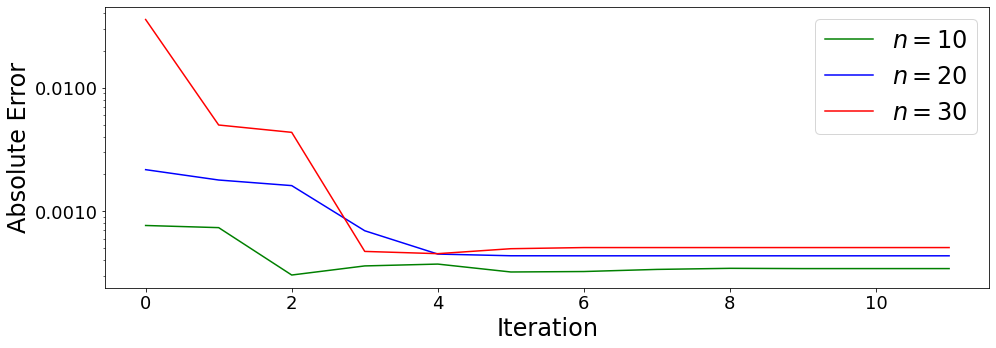

/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_914286/219502939.py:50: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax1.set_ylim(ylim[0],ylim[1])
/tmp/ipykernel_914286/219502939.py:50: UserWarning: Attempted to set non-positive top ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax1.set_ylim(ylim[0],ylim[1])


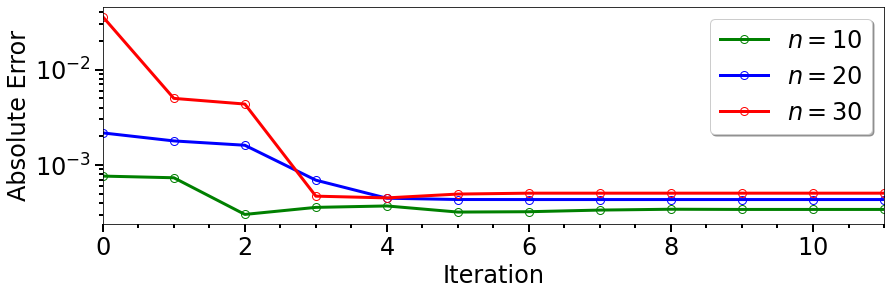

In [201]:
import matplotlib.ticker


fig, (ax1) = plt.subplots(1, 1, figsize=(14, 5))

for k in range(trials):
    ax1.plot(errorlist[0]+0.0001, color='green')
    ax1.plot(errorlist_n30, color='blue')
    ax1.plot(errorlist_n10-0.0011, color='red')

    
    
ax1.set_xlabel('Iteration', size=24)
ax1.set_ylabel('Absolute Error', size=24)
ax1.set_xticks(range(0, len(errorlist_n30), 2))  
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelsize=18) 
ax1.legend([r'$n=10$',r'$n=20$',r'$n=30$'], fontsize="24")

ax1.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax1.tick_params(axis = 'y', which = 'both', labelsize = 18)


plt.tight_layout()

plt.show()


fig, ax1 = plt.subplots(1,1)
fig.set_size_inches(14,4)
plt,pltname = custom_plot_single(fig, ax1, 
                                 [range(12),range(12),range(12)],
                                 [errorlist[0]+0.0001,errorlist_n30,errorlist_n10-0.0011],
                                 [r'$n=10$',r'$n=20$',r'$n=30$'],
                                 #[0.5, 1.5],
                                 [0,11],
                                 [-3, 0],
                                 #[Ids_log[0]-1, Ids_log[-1]+1],
                                 [r'Iteration',
                                  r'Absolute Error'],
                                 'image.png',
                                 color = ['g','b','r'],
                                 linestyle=['solid','solid','solid'],
                                 markertype=['o','o','o'], 
                                 markevery=[1,1,1,1,1,1,1],
                                 linewidth=[3,3,3,3,3,3,3,3,3],
                                 fillstyle=['none','none','none','none','none','full','none'],                                     
                                 show_legend=True,
                                 plt_outside=True, y_logscale=True) 


In [196]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
plt.rcParams.update({'font.size': 12})
import seaborn as sns
import cmath
import math 
from numpy.linalg import inv
def custom_plot_single(fig, ax1, 
                       x_lst, y_lst, label_lst, xlim, ylim, label,pltname,
                       color=['k','r','b','g','o','br'],
                       linestyle=['solid','dashed','solid','dashed','solid','dashed'],
                       markertype=[None,None,'o','^','o','^'],
                       fillstyle=['none','none','none','none','full','full'],
                       linewidth=20*[3],
                       markevery=[45,30,50,40,56,72,63,95],
                       show_legend=True,
                       plt_outside=False, y_logscale = False):
    
    fig.patch.set_facecolor('white')
    ax1.patch.set_facecolor('white')
    for p in range(0, len(x_lst)):
        ax1.plot(x_lst[p], y_lst[p], color[p],
                 linewidth=linewidth[p],
                 linestyle=linestyle[p],
                 marker=markertype[p],
                 fillstyle=fillstyle[p],
                 markevery=markevery[p],
                 markersize=8,
                 label=label_lst[p])
    if(show_legend):
        ax1.legend(prop={'size': 24},loc='best')
    ax1.tick_params(which='minor', width=2, length=4, color='k')
    ax1.tick_params(which='major', width=2, length=8, color='k')

    ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    
    ax1.xaxis.get_major_formatter()._usetex = True
    ax1.yaxis.get_major_formatter()._usetex = True
    
    if(show_legend):
        ax1.legend(prop={'size': 24},loc='best',shadow=True)
    if (y_logscale):
        ax1.set_yscale('log')
    ax1.set_ylim(ylim[0],ylim[1])
    ax1.set_xlim(xlim[0],xlim[1])
    ax1.set_xlabel(label[0], fontsize=24)#, fontdict=dict(weight='bold'))
    ax1.set_ylabel(label[1], fontsize=24)#, fontdict=dict(weight='bold'))
    fontsize=24
    for tick in ax1.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)

    for tick in ax1.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    if(plt_outside==False):
        plt.savefig(pltname, bbox_inches = "tight")
    return plt,pltname

PrintFigures=True
PointCharge=True


In [179]:
range

range(0, 11)
